# <span style="color:teal"> Lezione 3 </span>
## <span style="color:turquoise"> Esercizio 3.1 </span> 
In questo esercizio è stato chiesto di stimare numericamente il prezzo attuale delle opzioni finanziare europee di tipo call $C[S(0), 0]$ e put $P[S(0), 0]$ tramite una simulazione Monte Carlo con data blocking, utilizzando $M=5 \cdot 10^4$ lanci totali. Vengono implementati due metodi distinti, uno diretto e uno indiretto, entrambi fondati sul modello di Black-Scholes.  

Il modello di Black-Scholes descrive l'evoluzione temporale del prezzo di un asset $S(t)$ come un moto browniano geometrico:
$$S(t) = S(0) \exp\left[ \left(r-\frac{1}{2}\sigma^2\right)t+\sigma W(t)\right]$$
dove $S(0)$ è il prezzo iniziale dell'asset, $r$ è il tasso d'interesse risk-free, $\sigma$ è la volatilità, e $W(t)\sim \mathcal{N}(0,t)$ è il processo di Wiener, ossia una variabile aleatoria gaussiana di media nulla e varianza $t$.  

Il prezzo attuale ($t=0$) delle opzioni call e put è definito rispettivamente come:

$$ C[S(0), 0] = e^{-rT}\cdot \text{max}(S(t)-K,0)$$
$$ P[S(0), 0] = e^{-rT}\cdot \text{max}(K-S(t),0)$$

dove $T$ è il tempo di scadenza dell'opzione, $K$ è il prezzo di esercizio (strike price), ed $e^{-rT}$ è il fattore di sconto.


1. **Metodo diretto**: Il prezzo $S(T)$ alla scadenza viene campionato in un unico passo, sfruttando direttamente la soluzione analitica del modello, con $W(t)\sim \mathcal{N}(0,t) $ campionato direttamente:
$$S(t) = S(0) \exp\left[ \left(r-\frac{1}{2}\sigma^2\right)t+\sigma W(t)\right]$$

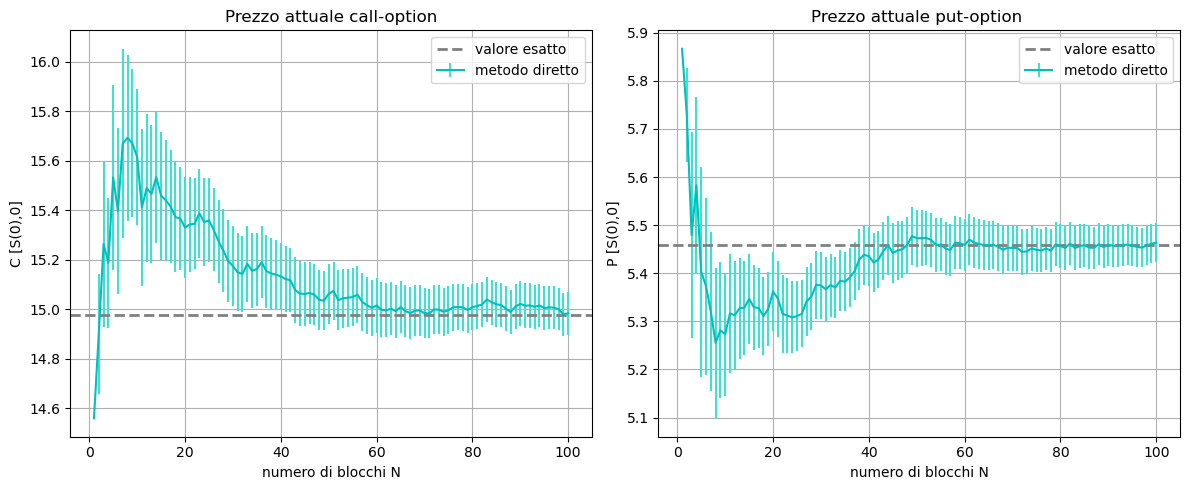

In [7]:
# metodo diretto
import matplotlib
import matplotlib.pyplot as plt
import math

import scipy
from scipy.special import erf

import numpy as np
from numpy import exp
from numpy.lib.scimath import log, sqrt

# --------- calcolo call e put esatte ---------------------------------------------
S0 = 100.
K = 100.
T = 1.
r = 0.1
sigma = 0.25
t=0

def N(x):
    return 0.5 * (1. + erf(x / sqrt(2.)))

def black_scholes(S0, K, T, r, sigma):
    d1 = 1./(sigma * sqrt(T)) * (log(S0 / K) + (r + (sigma**2) / 2.) * T)
    d2 = d1 - sigma * sqrt(T)
    C = S0 * N(d1) - K * exp(-r * T) * N(d2)
    P = S0 *(N(d1) - 1.) - K * exp(-r * T) * (N(d2)-1.)
    return C, P


call, put = black_scholes(S0, K, T, r, sigma)


# -------- carico i dati da file ----------------------------------------------

datiC=np.loadtxt("Esercizio3.1/datiC1.txt")
x=datiC[:,0] 
sum_progC=datiC[:,1]
err_progC=datiC[:,2]

datiP=np.loadtxt("Esercizio3.1/datiP1.txt")
sum_progP=datiP[:,1]
err_progP=datiP[:,2]


# -------- faccio i grafici -------------------------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.errorbar(x,sum_progC,yerr=err_progC, color='c', ecolor='turquoise', label="metodo diretto")
ax1.axhline(y=call, color='grey', linestyle= '--',lw=2, label="valore esatto")
ax1.set_xlabel('numero di blocchi N')
ax1.set_ylabel('C [S(0),0]')
ax1.set_title("Prezzo attuale call-option")
ax1.grid(True)
ax1.legend()


ax2.errorbar(x,sum_progP,yerr=err_progP, color='c', ecolor='turquoise', label="metodo diretto")
ax2.axhline(y=put, color='grey', linestyle= '--',lw=2, label="valore esatto")
ax2.set_xlabel('numero di blocchi N')
ax2.set_ylabel('P [S(0),0]')
ax2.set_title("Prezzo attuale put-option ")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()


2. **Metodo discreto**: Poiché il processo di Wiener $W(t)$ possiede incrementi indipendenti, è possibile costruire il percorso temporale di $S(t)$ passo dopo passo. Suddividendo l'intervallo $[0,T]$ in $10^2$ sottointervalli, il prezzo viene aggiornato ricorsivamente secondo la seguente espressione, dove $ Z_{i+1}\sim \mathcal{N}(0,1)$:
$$S(t_{i+1}) = S(t_i) \exp\left[ \left(\mu-\frac{1}{2}\sigma^2\right)(t_{i+1}-t_i) +\sigma Z_{i+1}\sqrt{t_{i+1}-t_i}\right]$$

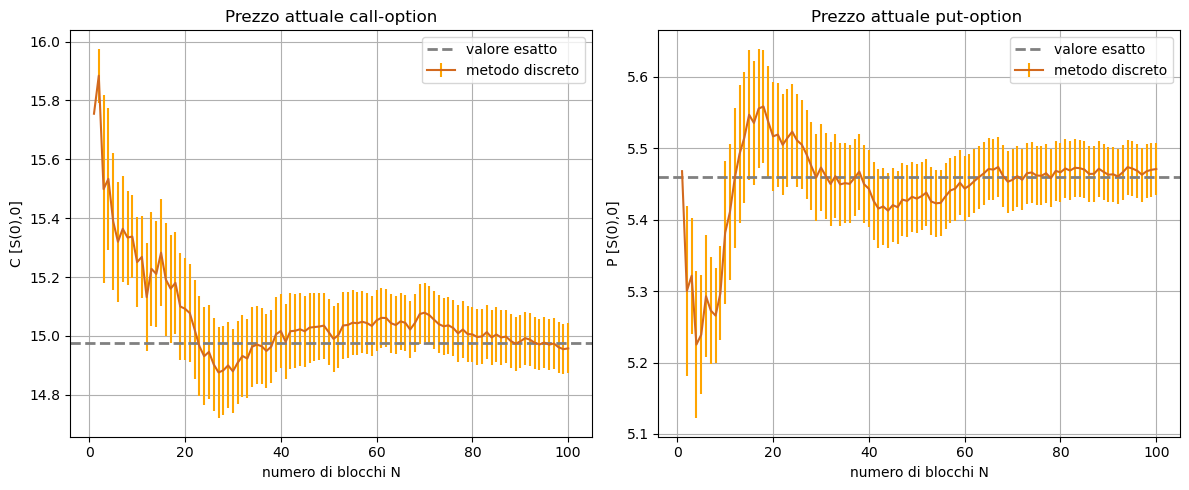

In [4]:
# metodo discreto

# -------- carico i dati da file ----------------------------------------------

datiC2=np.loadtxt("Esercizio3.1/datiC2.txt")
sum_progC2=datiC2[:,1]
err_progC2=datiC2[:,2]

datiP2=np.loadtxt("Esercizio3.1/datiP2.txt")
sum_progP2=datiP2[:,1]
err_progP2=datiP2[:,2]

# -------- faccio i grafici ---------------------------------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.errorbar(x,sum_progC2,yerr=err_progC2, color='chocolate', ecolor='orange', label="metodo discreto")
ax1.axhline(y=call, color='grey', linestyle= '--',lw=2, label="valore esatto")
ax1.set_xlabel('numero di blocchi N')
ax1.set_ylabel('C [S(0),0]')
ax1.set_title("Prezzo attuale call-option")
ax1.grid(True)
ax1.legend()

ax2.errorbar(x,sum_progP2,yerr=err_progP2, color='chocolate', ecolor='orange', label="metodo discreto")
ax2.axhline(y=put, color='grey', linestyle= '--',lw=2, label="valore esatto")
ax2.set_xlabel('numero di blocchi N')
ax2.set_ylabel('P [S(0),0]')
ax2.set_title("Prezzo attuale put-option ")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

In entrambi i metodi le stime di call e put convergono ai rispettivi valori esatti di Black-Scholes all'aumentare del numero di blocchi $N$ con un errore statistico che decresce correttamente come $\frac{1}{\sqrt{N}}$, in accordo con il teorema del limite centrale.

I risultati ottenuti con i due approcci risultano tra loro compatibili, confermandone l'equivalenza matematica: per gli scopi di questo esercizio nessuno dei due metodi è da preferire all'altro.